# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 46    |  |
| :-------------|:-------------|
| Oskar van Velze| 6044247 |
| Rune Veraart | 6439748 |
| Vera Reeringh | 6321046 |
| Planning Groep: 46     |Tijdstip / Tijdspanne  |
|---|---|
| Condensator af| 12:15 |
| Sensor af | 16: 15 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:15-16:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

epsilon0 = 8.85*10**-12
A = 0.01
d=0.001
def capaciteit(epsilon_r, A, d):
    C_plaat = epsilon0 * epsilon_r * A/d *1e12
    return C_plaat

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = capaciteit(1, 1e-2, 1e-3)


print(f"Berekende capaciteit plaatcondensator groep 46 is {C:.1f} pF")



Berekende capaciteit plaatcondensator groep 46 is 88.5 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](condensator.jpeg)
![scope meting 2](scope.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 46| 88.5 pF | 0.44 V | 0.483 V |96.1 pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](3.3woensdagtoepassingenbedenken.jpg)


Schets 1 : $\epsilon_r$  verandering gebruiken voor meten gewicht


Schets 2: Oppervlakte verandering gebruiken voor meten waterpeil


Schets 3: dikte verandering gebruiken voor meten aantal mol lucht met n = P * V / R * T

## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die gewicht meet, mbv de permitiviteit van een object tussen condensatoren

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schetsfinalopstelling.jpeg)

Hier is het voor- en zij aanzicht te zien van de sensor die we gaan bouwen. Het idee is dat doordat de isolerende plaat door een gewicht naar beneden en boven kan bewegen, zodat de permitiviteit $\epsilon_r$ en dus ook de capaciteit verandert. Zo is het mogelijk om een relatie tussen de capaciteit en het gewicht te vinden. Het wordt dus een weegschaal waarbij we de waarde van $\epsilon_r$ met de sensor meten.

In [3]:
from scipy.optimize import curve_fit

g = 9.81 # valversnelling
def veerconstante(u,c,b):
    m = u * c / g + b
    return m


gewicht_array = np.array([646, 0, 486, 283.5, 143, 53.7, 316])*1e-3
x_array = np.array([38.3, 13.25, 32.5, 25.6, 19.8, 17.1, 26.5])*1e-2

popt, pcov = curve_fit(veerconstante, x_array, gewicht_array)
Cv = popt[0]
b = popt[1]

print ('c:', Cv, 'N/m')
print ('b:', b)


c: 25.971377842342594 N/m
b: -0.37902763004379864


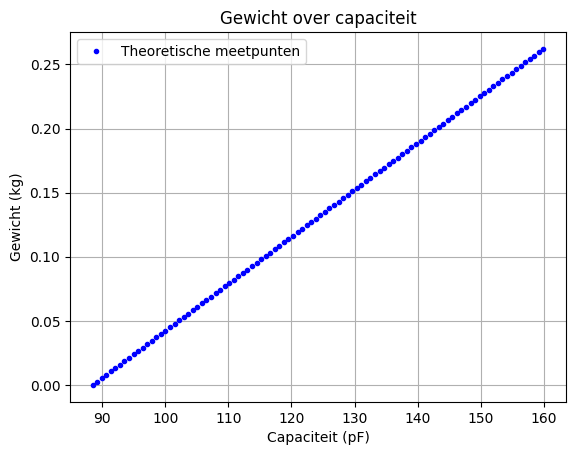

De minimale capaciteit is 88.5 pF
De maximale capaciteit is 159.9195 pF


In [4]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

import numpy as np
import matplotlib.pyplot as plt

# C = epsilon0*epsilonr * A/d
# C_lucht = 52.11, met Vout = 0.63V
# C_materiaal = 52.11 / 0.63 * 1.138 (1.138V is gemeten V_out met materiaal)
# C_materiaal = 94.1335979
# epsilonr = C*d/epsilon0 * A = 1.807

def capaciteit(epsilon_r, A, d):
    C_plaat = epsilon0 * epsilon_r * A/d *1e12
    return C_plaat

def func_gewicht (u,c_veer):
    F = -c_veer * u
    m = F / g
    return m

permitiviteit = 1.807

e_r = np.linspace(1,permitiviteit,100)
cap = capaciteit(e_r, 0.01, 0.001)

g = -9.81 # valversnelling
#c_veer = Cv # gevonden veerconstante

u = np.arange(0,100,1) / 1000 # uitwijking in meter
gewicht =  func_gewicht(u, Cv)

plt.figure()
plt.title ( 'Gewicht over capaciteit')
plt.plot (cap, gewicht, 'b.', label = 'Theoretische meetpunten')
plt.xlabel('Capaciteit (pF)')
plt.ylabel ('Gewicht (kg)')
plt.legend()
plt.grid()
plt.show()

min_cap = np.min(cap) # theoretische minimale capaciteit
max_cap = np.max(cap) # theoretische minimale capaciteit

print ('De minimale capaciteit is', round(min_cap,4), 'pF')
print ('De maximale capaciteit is', round(max_cap,4), 'pF')

## Opdracht 5: Invullen tabel LTSpice.

![LTSpice](3.3LTSpicesims.png)

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 52 pF | 261.23 mV |
| gemiddelde capaciteit|425 pF | 2.05694 V |
| maximale capaciteit| 798 pF | 3.54933 V |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Opstelling1.jpeg)
![meting 1](meting1.jpeg)

Hierboven is de eerste meting te zien. Er hangt geen gewicht aan de veer en dus is de permitiviteit gelijk aan de permitiviteit van de isolerende plaat, omdat de isolerende plaat volledig tussen de twee geleidende platen zit. De isolerende plaat is van onbekend materiaal.
![meting 2](Opstelling2.jpeg)
![meting 2](meting2.jpeg)

Hierboven is de tweede meting te zien. Omdat er een gewicht aan hangt, is de permitiviteit ergens tussen de permitiviteit van lucht (1) en die van de plaat (1.807). Het idee is dus dat het zo mogelijk is om op basis van de permitiviteit te veranderen waarbij we de capaciteit meten en zo een relatie te vinden tussen het gewicht en de capaciteit.


## Opdracht 7: Plot de kalibratiegrafiek.

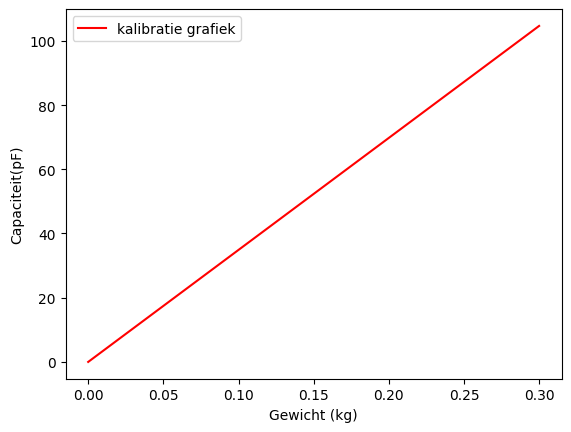

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.


g = 9.812
epsilon_plaat = 15.33
epsilon_0 = 8.854*1e-12
epsilon_lucht = 1.00056
m_waardes_voor_plot = np.linspace(0, 300*1e-3, 100)
gefitte_veerconstante = 224.27
breedte_plaat = 0.1
A = 1e-2
d = 1.7e-3

cap = capaciteit(e_r, 0.01, 0.001)
gewicht =  func_gewicht(u, Cv)


#def C_theorie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    C = epsilon_0 * (10 * u * epsilon_lucht + (1-(10 * u * epsilon_plaat))) * (A / d) / 10
#    return C

#def kalibratie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
#    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
#    while u < 0.1: 
#        return Cplaat + Clucht
#    while u >= 0.1: 
#        return epsilon_0 * epsilon_lucht * (A/d)

def uitweiking(m, veerconstante):
    u = ((m) * g)/(-veerconstante)
    return u

def cap_met_twee(u):
    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
    return Cplaat + Clucht

def cap_met_een(u):
    return epsilon_0 * epsilon_lucht * (A+(u*0)/d)

u_waardes = uitweiking(m_waardes_voor_plot, gefitte_veerconstante)
kalibratie = np.zeros(len(m_waardes_voor_plot))
for i in range(len(u_waardes)):
    if u_waardes[i] < 0.1:
        kalibratie[i] = cap_met_twee(u_waardes[i])
    if u_waardes[i] >= 0.1:
        kalibratie[i] = cap_met_een(u_waardes[i])

plt.figure()
plt.plot(m_waardes_voor_plot, kalibratie*1e12, 
         'r-', label = 'kalibratie grafiek')
#plt.plot (cap, gewicht, 'b--', label = 'Theoretische meetpunten')
plt.ylabel('Capaciteit(pF)')
plt.xlabel('Gewicht (kg)')
#plt.ylim(0,130)
#plt.xlim(0,0.3)
plt.legend()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1 : betere manier om platen op vaste afstand van elkaar te houden
* verbetering 2 : makkelijkere manier om gewicht aan plaat te hangen, kleinere plaat


## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](finalOpstelling.jpeg)

Gefitte veerconstante: 13998445756.18 N/m
Gefitte beginmassa: 3917423.4076 kg


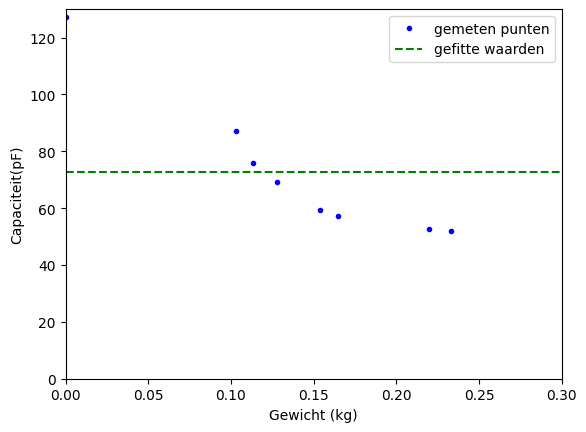

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij


m_array = np.array([0,103,113.6,128.1,154,165,219.7,233.3])*1e-3
f_array = np.array([127.2,87.1,75.8,69.2,59.5,57.1,52.6,52.1])*1e-12


A = 1e-2
d = 1.7e-3
epsilon_0 = 8.854*1e-12
epsilon_r_lucht = 1.00056
epsilon_r_plaat = 15.33 # bepaald door plaat tussen de condensator platen te drukken en te vergelijken met lucht op dezelfde afstand
veerc = Cv              # deze meting is waarschijnlijk inaccuraat, dus we fitten liever voor Cv

def fit(m, m0, veerconstante):
    u = ((m+m0) * g)/(-veerconstante)
    C = epsilon_0 * (10 * u * epsilon_r_lucht + (1-10 * u * epsilon_r_plaat)) * (A / d)
    return C

var, cov = curve_fit(fit, m_array, f_array, p0=[200*1e-3, 15])
massa_waarden = np.linspace(0, 300*1e-3, 200)
m0 = var[0]
veerconstante = var[1]
fitresultaten = fit(massa_waarden, m0, veerconstante)
print(f"Gefitte veerconstante: {veerconstante:.2f} N/m")
print(f"Gefitte beginmassa: {m0:.4f} kg")


plt.figure()
plt.plot(m_array, f_array*1e12,'b.', label = 'gemeten punten')
plt.plot(massa_waarden, fitresultaten*1e12, 'g--', label = 'gefitte waarden')
plt.ylabel('Capaciteit(pF)')
plt.xlabel('Gewicht (kg)')
plt.ylim(0,130)
plt.xlim(0,0.3)
plt.legend()

## Opdracht 10: Vul hieronder de conclusie in.

De opstelling werkte redelijk, maar onze range was veel lager dan dat we oorspronkelijk hadden verwacht. We haddan vantevoren metingen gedaan met de isolerende plaat op de tafel, voor het bouwen van de uiteindelijke opstelling, om een indruk te krijgen van hoe groot de range van onze sensor zou zijn, en die metingen leken gunstig. Maar in de praktijk was de range veel lager. Dit kwam doordat de platen niet zo dicht bij elkaar konden blijven als we vantevoren dachten, omdat een hangende plaat erdoorheen moest kunnen, en er zaten luchtgleuven om de plaat heen wanneer deze niet de ruimte tussen de platen volledig innam. De nauwkeurigheid van onze metingen ging daarom omlaag.

Uiteindelijk hebben we alsnog succesvol een omrekening van capiciteit naar gewicht gemaakt door de door ons bepaalde veerconstante, die erg onzeker was, weg te laten en in plaats daarvan gebruik te maken van een curvefit om de veerconstante te bepalen. Hbv deze methode hebben we uiteindelijk een plot van onze omrekening kunnen maken, deze bevat door tijdstekort geen onzekerheden.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

## leerdoel 1 

![drie schetsen](3.3woensdagtoepassingenbedenken.jpg)

![uitgewerkte schets](schetsfinalopstelling.jpeg)

Hier is het voor- en zij aanzicht te zien van de sensor die we gaan bouwen. Het idee is dat doordat de isolerende plaat door een gewicht naar beneden en boven kan bewegen, zodat de permitiviteit $\epsilon_r$ en dus ook de capaciteit verandert. Zo is het mogelijk om een relatie tussen de capaciteit en het gewicht te vinden. Het wordt dus een weegschaal waarbij we de waarde van $\epsilon_r$ met de sensor meten.

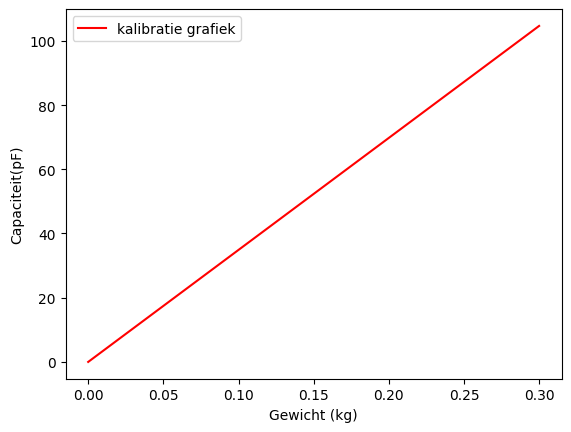

In [8]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.


g = 9.812
epsilon_plaat = 15.33
epsilon_0 = 8.854*1e-12
epsilon_lucht = 1.00056
m_waardes_voor_plot = np.linspace(0, 300*1e-3, 100)
gefitte_veerconstante = 224.27
breedte_plaat = 0.1
A = 1e-2
d = 1.7e-3

cap = capaciteit(e_r, 0.01, 0.001)
gewicht =  func_gewicht(u, Cv)


#def C_theorie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    C = epsilon_0 * (10 * u * epsilon_lucht + (1-(10 * u * epsilon_plaat))) * (A / d) / 10
#    return C

#def kalibratie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
#    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
#    while u < 0.1: 
#        return Cplaat + Clucht
#    while u >= 0.1: 
#        return epsilon_0 * epsilon_lucht * (A/d)

def uitweiking(m, veerconstante):
    u = ((m) * g)/(-veerconstante)
    return u

def cap_met_twee(u):
    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
    return Cplaat + Clucht

def cap_met_een(u):
    return epsilon_0 * epsilon_lucht * (A+(u*0)/d)

u_waardes = uitweiking(m_waardes_voor_plot, gefitte_veerconstante)
kalibratie = np.zeros(len(m_waardes_voor_plot))
for i in range(len(u_waardes)):
    if u_waardes[i] < 0.1:
        kalibratie[i] = cap_met_twee(u_waardes[i])
    if u_waardes[i] >= 0.1:
        kalibratie[i] = cap_met_een(u_waardes[i])

plt.figure()
plt.plot(m_waardes_voor_plot, kalibratie*1e12, 
         'r-', label = 'kalibratie grafiek')
#plt.plot (cap, gewicht, 'b--', label = 'Theoretische meetpunten')
plt.ylabel('Capaciteit(pF)')
plt.xlabel('Gewicht (kg)')
#plt.ylim(0,130)
#plt.xlim(0,0.3)
plt.legend()


## leerdoel 2 

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 52 pF | 261.23 mV |
| gemiddelde capaciteit|425 pF | 2.05694 V |
| maximale capaciteit| 798 pF | 3.54933 V |

![foto sensor](finalOpstelling.jpeg)


## leerdoel 3 
De onzekerheden zijn door tijdstekort niet doorgewerkt. Deze zullen wel aanzienlijk hoog zijn omdat onze opstelling best wel onstabiel was, waardoor we niet de accuratie konden krijgen die we graag hadden gewild. We schatten dat de onzekerheid groter wordt in bij metingen waar de isolerende plaat half tussen de geleidende platen hing, omdat daar onzekerheid in het gewicht van toepassing is en onzekerheid in het meten van de capaciteit. De onzekerheid is het kleinst waar de isolerende plaat helemaal er tussen zit of helemaal niet.

De opstelling werkte redelijk, maar onze range was veel lager dan dat we oorspronkelijk hadden verwacht. We haddan vantevoren metingen gedaan met de isolerende plaat op de tafel, voor het bouwen van de uiteindelijke opstelling, om een indruk te krijgen van hoe groot de range van onze sensor zou zijn, en die metingen leken gunstig. Maar in de praktijk was de range veel lager. Dit kwam doordat de platen niet zo dicht bij elkaar konden blijven als we vantevoren dachten, omdat een hangende plaat erdoorheen moest kunnen, en er zaten luchtgleuven om de plaat heen wanneer deze niet de ruimte tussen de platen volledig innam. De nauwkeurigheid van onze metingen ging daarom omlaag.

Uiteindelijk hebben we alsnog succesvol een omrekening van capiciteit naar gewicht gemaakt door de door ons bepaalde veerconstante, die erg onzeker was, weg te laten en in plaats daarvan gebruik te maken van een curvefit om de veerconstante te bepalen. Hbv deze methode hebben we uiteindelijk een plot van onze omrekening kunnen maken, deze bevat door tijdstekort geen onzekerheden.

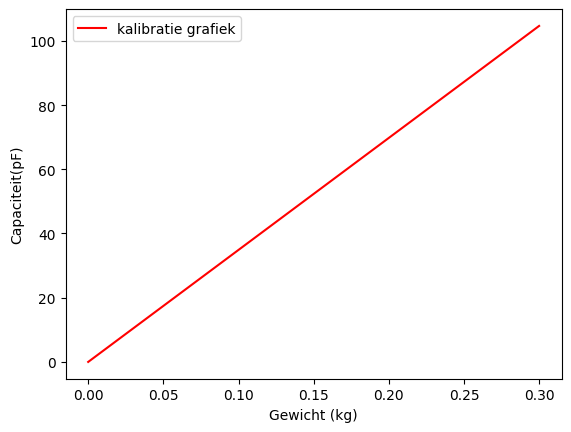

In [9]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.


g = 9.812
epsilon_plaat = 15.33
epsilon_0 = 8.854*1e-12
epsilon_lucht = 1.00056
m_waardes_voor_plot = np.linspace(0, 300*1e-3, 100)
gefitte_veerconstante = 224.27
breedte_plaat = 0.1
A = 1e-2
d = 1.7e-3

cap = capaciteit(e_r, 0.01, 0.001)
gewicht =  func_gewicht(u, Cv)


#def C_theorie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    C = epsilon_0 * (10 * u * epsilon_lucht + (1-(10 * u * epsilon_plaat))) * (A / d) / 10
#    return C

#def kalibratie(m, veerconstante):
#    u = ((m) * g)/(-veerconstante)
#    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
#    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
#    while u < 0.1: 
#        return Cplaat + Clucht
#    while u >= 0.1: 
#        return epsilon_0 * epsilon_lucht * (A/d)

def uitweiking(m, veerconstante):
    u = ((m) * g)/(-veerconstante)
    return u

def cap_met_twee(u):
    Cplaat = epsilon_0 * epsilon_plaat * (breedte_plaat * -(u))/d
    Clucht = epsilon_0 * epsilon_lucht * (breedte_plaat * -(0.1+u))
    return Cplaat + Clucht

def cap_met_een(u):
    return epsilon_0 * epsilon_lucht * (A+(u*0)/d)

u_waardes = uitweiking(m_waardes_voor_plot, gefitte_veerconstante)
kalibratie = np.zeros(len(m_waardes_voor_plot))
for i in range(len(u_waardes)):
    if u_waardes[i] < 0.1:
        kalibratie[i] = cap_met_twee(u_waardes[i])
    if u_waardes[i] >= 0.1:
        kalibratie[i] = cap_met_een(u_waardes[i])

plt.figure()
plt.plot(m_waardes_voor_plot, kalibratie*1e12, 
         'r-', label = 'kalibratie grafiek')
#plt.plot (cap, gewicht, 'b--', label = 'Theoretische meetpunten')
plt.ylabel('Capaciteit(pF)')
plt.xlabel('Gewicht (kg)')
#plt.ylim(0,130)
#plt.xlim(0,0.3)
plt.legend()


Gefitte veerconstante: 13998445756.18 N/m
Gefitte beginmassa: 3917423.4076 kg


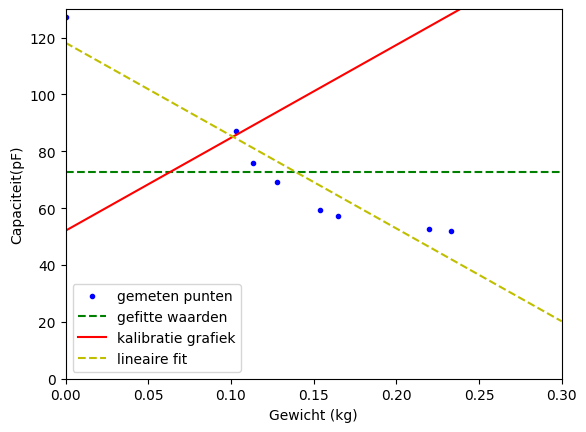

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij


m_array = np.array([0,103,113.6,128.1,154,165,219.7,233.3])*1e-3
f_array = np.array([127.2,87.1,75.8,69.2,59.5,57.1,52.6,52.1])*1e-12


A = 1e-2
d = 1.7e-3
epsilon_0 = 8.854*1e-12
epsilon_r_lucht = 1.00056
epsilon_r_plaat = 15.33 # bepaald door plaat tussen de condensator platen te drukken en te vergelijken met lucht op dezelfde afstand
veerc = gefitte_veerconstante             # deze meting is waarschijnlijk inaccuraat, dus we fitten liever voor Cv

def fit(m, m0, veerconstante):
    u = ((m+m0) * g)/(-veerconstante)
    C = epsilon_0 * (10 * u * epsilon_r_lucht + (1-10 * u * epsilon_r_plaat)) * (A / d)
    return C


#-----------LINEAIRE FIT------------------
def fitnul(x, a, b):
    return a*x + b

bvar, bcov = curve_fit(fitnul, m_array, f_array)
m0_test = bvar[0]
veerconstante_test = bvar[1]
#---------------------------------


def C_theorie(m, veerconstante):
    u = ((m) * g)/(-veerconstante)
    C = epsilon_0 * (10 * u * epsilon_r_lucht + (1-10 * u * epsilon_r_plaat)) * (A / d)
    return C

var, cov = curve_fit(fit, m_array, f_array, p0=[200*1e-3, 15])
massa_waarden = np.linspace(0, 300*1e-3, 200)
m0 = var[0]
veerconstante = var[1]
fitresultaten = fit(massa_waarden, m0, veerconstante)
print(f"Gefitte veerconstante: {veerconstante:.2f} N/m")
print(f"Gefitte beginmassa: {m0:.4f} kg")



plt.figure()
plt.plot(m_array, f_array*1e12,'b.', label = 'gemeten punten')
plt.plot(massa_waarden, fitresultaten*1e12, 'g--', label = 'gefitte waarden')
plt.plot(massa_waarden, C_theorie(massa_waarden, gefitte_veerconstante)*1e12, 
         'r-', label = 'kalibratie grafiek')
plt.plot(m_waardes_voor_plot, fitnul(m_waardes_voor_plot, bvar[0], bvar[1])*1e12, 
         'y--', label = 'lineaire fit')
plt.ylabel('Capaciteit(pF)')
plt.xlabel('Gewicht (kg)')
plt.ylim(0,130)
plt.xlim(0,0.3)
plt.legend()